In [1]:
import matplotlib
matplotlib.use("Agg")
import numpy as np
import time
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn

np.random.seed(42)


## Kalman 分解與相關性工具

定義高低兩個 component 相關性摘要、Kalman filter，以及利用 Kalman filter 將觀測序列拆成線性與非線性部分的函式。

In [2]:
def component_correlation_summary(linear_part, nonlinear_part):
    linear_part = np.asarray(linear_part, dtype=float)
    nonlinear_part = np.asarray(nonlinear_part, dtype=float)

    if linear_part.shape != nonlinear_part.shape:
        raise ValueError("linear_part and nonlinear_part must have the same shape.")

    if linear_part.size < 2:
        return {
            "pearson_corr": np.nan,
            "abs_pearson_corr": np.nan,
            "corr_sq": np.nan,
            "covariance": np.nan,
        }

    pearson_corr = float(np.corrcoef(linear_part, nonlinear_part)[0, 1])
    covariance = float(np.cov(linear_part, nonlinear_part, ddof=1)[0, 1])
    return {
        "pearson_corr": pearson_corr,
        "abs_pearson_corr": abs(pearson_corr),
        "corr_sq": pearson_corr ** 2,
        "covariance": covariance,
    }


def kalman_filter(observations, process_variance=0.5, measurement_variance=10.0, initial_error=1.0):
    initial_estimate = float(observations[0])
    estimated_state = initial_estimate
    estimate_error = float(initial_error)
    estimated_states = []

    for measurement in observations:
        predicted_state = estimated_state
        predicted_error = estimate_error + process_variance

        kalman_gain = predicted_error / (predicted_error + measurement_variance)
        estimated_state = predicted_state + kalman_gain * (measurement - predicted_state)
        estimate_error = (1.0 - kalman_gain) * predicted_error
        estimated_states.append(estimated_state)

    return np.array(estimated_states, dtype=float)


def decompose_with_simple_kf(series, process_variance=0.5, measurement_variance=10.0):
    estimated_low = kalman_filter(
        series,
        process_variance=process_variance,
        measurement_variance=measurement_variance,
        initial_error=1.0,
    )
    estimated_high = np.array(series, dtype=float) - estimated_low
    return estimated_low, estimated_high


## Joint DistPred 模型與訓練工具

這一段定義 joint window 建立方式、MLP 模型、loss function，以及 joint DistPred 的訓練與遞迴預測流程。

In [3]:
def create_joint_windows(low_series, high_series, window_size):
    features = []
    targets = []
    for idx in range(window_size, len(low_series)):
        low_window = np.asarray(low_series[idx - window_size:idx], dtype=float)
        high_window = np.asarray(high_series[idx - window_size:idx], dtype=float)
        joint_window = np.column_stack([low_window, high_window]).reshape(-1)
        features.append(joint_window)
        targets.append([float(low_series[idx]), float(high_series[idx])])
    return np.asarray(features, dtype=float), np.asarray(targets, dtype=float)


class JointDistPredMLP(nn.Module):
    def __init__(self, input_dim, ensemble_size):
        super().__init__()
        self.ensemble_size = ensemble_size
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, ensemble_size * 2),
        )

    def forward(self, x):
        out = self.net(x)
        return out.view(-1, self.ensemble_size, 2)


def joint_distpred_loss(pred_ensemble, y_true):
    y_true = y_true.unsqueeze(1)
    calibration_term = torch.abs(pred_ensemble - y_true).mean(dim=(1, 2))
    pairwise = pred_ensemble.unsqueeze(2) - pred_ensemble.unsqueeze(1)
    diversity_term = torch.abs(pairwise).mean(dim=(1, 2, 3))
    mean_term = torch.square(pred_ensemble.mean(dim=1) - y_true.squeeze(1)).mean(dim=1)
    return (calibration_term - 0.5 * diversity_term + 0.05 * mean_term).mean()


def fit_joint_distpred_bundle(low_train, high_train, window_size, ensemble_size=50, epochs=250, learning_rate=1e-3):
    x_train, y_train = create_joint_windows(low_train, high_train, window_size)
    if len(x_train) == 0:
        raise ValueError("Not enough samples for joint DistPred windows. Increase training size or reduce window_size.")

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
    x_train_scaled = x_scaler.fit_transform(x_train)
    y_train_scaled = y_scaler.fit_transform(y_train).astype(np.float32)

    x_tensor = torch.tensor(x_train_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

    model = JointDistPredMLP(input_dim=x_train.shape[1], ensemble_size=ensemble_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        pred_ensemble = model(x_tensor)
        loss = joint_distpred_loss(pred_ensemble, y_tensor)
        loss.backward()
        optimizer.step()

    low_q = np.quantile(low_train, [0.01, 0.99])
    high_q = np.quantile(high_train, [0.01, 0.99])
    low_iqr = np.subtract(*np.quantile(low_train, [0.75, 0.25]))
    high_iqr = np.subtract(*np.quantile(high_train, [0.75, 0.25]))
    low_margin = max(0.5 * low_iqr, 0.25)
    high_margin = max(0.5 * high_iqr, 0.25)
    clip_bounds = (
        (float(low_q[0] - low_margin), float(low_q[1] + low_margin)),
        (float(high_q[0] - high_margin), float(high_q[1] + high_margin)),
    )

    return {
        "model": model.eval(),
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "clip_bounds": clip_bounds,
        "window_size": window_size,
        "ensemble_size": ensemble_size,
    }


def recursive_joint_distpred_forecast(bundle, low_history, high_history, horizon, window_size):
    ensemble_size = bundle["ensemble_size"]
    low_hist = np.asarray(low_history[-window_size:], dtype=float)
    high_hist = np.asarray(high_history[-window_size:], dtype=float)
    base_history = np.column_stack([low_hist, high_hist])
    rolling_histories = np.tile(base_history.reshape(1, window_size, 2), (ensemble_size, 1, 1))
    low_paths = np.zeros((ensemble_size, horizon), dtype=float)
    high_paths = np.zeros((ensemble_size, horizon), dtype=float)

    for step_idx in range(horizon):
        features = rolling_histories.reshape(ensemble_size, window_size * 2)
        features_scaled = bundle["x_scaler"].transform(features)
        with torch.no_grad():
            pred_scaled = bundle["model"](torch.tensor(features_scaled, dtype=torch.float32)).cpu().numpy()

        diag_scaled = pred_scaled[np.arange(ensemble_size), np.arange(ensemble_size), :]
        diag_pred = bundle["y_scaler"].inverse_transform(diag_scaled)
        next_low = np.clip(diag_pred[:, 0], bundle["clip_bounds"][0][0], bundle["clip_bounds"][0][1])
        next_high = np.clip(diag_pred[:, 1], bundle["clip_bounds"][1][0], bundle["clip_bounds"][1][1])

        low_paths[:, step_idx] = next_low
        high_paths[:, step_idx] = next_high

        next_pair = np.stack([next_low, next_high], axis=1).reshape(ensemble_size, 1, 2)
        rolling_histories = np.concatenate([rolling_histories[:, 1:, :], next_pair], axis=1)

    return low_paths, high_paths


def fit_joint_distpred_component(low_train, high_train, horizon, window_size, ensemble_size=50):
    bundle = fit_joint_distpred_bundle(
        low_train,
        high_train,
        window_size,
        ensemble_size=ensemble_size,
    )
    low_samples, high_samples = recursive_joint_distpred_forecast(
        bundle,
        low_train,
        high_train,
        horizon,
        window_size,
    )
    low_forecast = np.mean(low_samples, axis=0)
    high_forecast = np.mean(high_samples, axis=0)
    return low_forecast, high_forecast, low_samples, high_samples, bundle


def hybrid_point_forecast(train_series, horizon, window_size=15, ensemble_size=50):
    estimated_low, estimated_high = decompose_with_simple_kf(train_series)
    low_forecast, high_forecast, low_samples, high_samples, bundle = fit_joint_distpred_component(
        estimated_low,
        estimated_high,
        horizon,
        window_size=window_size,
        ensemble_size=ensemble_size,
    )
    final_samples = low_samples + high_samples
    final_forecast = np.mean(final_samples, axis=0)

    return {
        "estimated_low": estimated_low,
        "estimated_high": estimated_high,
        "low_forecast": low_forecast,
        "high_forecast": high_forecast,
        "low_samples": low_samples,
        "high_samples": high_samples,
        "joint_bundle": bundle,
        "final_samples": final_samples,
        "final_forecast": final_forecast,
    }


def timed_hybrid_point_forecast(train_series, horizon, window_size=15, ensemble_size=50):
    timing = {
        "kf_decomposition": 0.0,
        "joint_distpred_fit_forecast": 0.0,
    }

    kf_start = time.perf_counter()
    estimated_low, estimated_high = decompose_with_simple_kf(train_series)
    timing["kf_decomposition"] += time.perf_counter() - kf_start

    joint_start = time.perf_counter()
    low_forecast, high_forecast, low_samples, high_samples, bundle = fit_joint_distpred_component(
        estimated_low,
        estimated_high,
        horizon,
        window_size=window_size,
        ensemble_size=ensemble_size,
    )
    timing["joint_distpred_fit_forecast"] += time.perf_counter() - joint_start

    final_samples = low_samples + high_samples
    final_forecast = np.mean(final_samples, axis=0)

    return {
        "estimated_low": estimated_low,
        "estimated_high": estimated_high,
        "low_forecast": low_forecast,
        "high_forecast": high_forecast,
        "low_samples": low_samples,
        "high_samples": high_samples,
        "joint_bundle": bundle,
        "final_samples": final_samples,
        "final_forecast": final_forecast,
    }, timing


## 繪圖工具

這一段提供互動圖與 component 相關性圖的繪製函式，用來觀察線性與非線性部分之間的關係。

In [4]:
def save_interaction_plot(bundle, low_history, high_history, output_path, grid_points=41):
    window_size = bundle["window_size"]
    ensemble_size = bundle["ensemble_size"]
    base_low = np.asarray(low_history[-window_size:], dtype=float)
    base_high = np.asarray(high_history[-window_size:], dtype=float)

    low_min, low_max = bundle["clip_bounds"][0]
    high_min, high_max = bundle["clip_bounds"][1]
    low_grid = np.linspace(low_min, low_max, grid_points)
    high_grid = np.linspace(high_min, high_max, grid_points)

    mean_surface = np.zeros((grid_points, grid_points), dtype=float)
    width_surface = np.zeros((grid_points, grid_points), dtype=float)

    for i, low_val in enumerate(low_grid):
        for j, high_val in enumerate(high_grid):
            low_window = base_low.copy()
            high_window = base_high.copy()
            low_window[-1] = low_val
            high_window[-1] = high_val

            features = np.column_stack([low_window, high_window]).reshape(1, -1)
            features = np.repeat(features, ensemble_size, axis=0)
            features_scaled = bundle["x_scaler"].transform(features)
            with torch.no_grad():
                pred_scaled = bundle["model"](torch.tensor(features_scaled, dtype=torch.float32)).cpu().numpy()

            diag_scaled = pred_scaled[np.arange(ensemble_size), np.arange(ensemble_size), :]
            diag_pred = bundle["y_scaler"].inverse_transform(diag_scaled)
            next_low = np.clip(diag_pred[:, 0], bundle["clip_bounds"][0][0], bundle["clip_bounds"][0][1])
            next_high = np.clip(diag_pred[:, 1], bundle["clip_bounds"][1][0], bundle["clip_bounds"][1][1])
            final_samples = next_low + next_high

            mean_surface[j, i] = np.mean(final_samples)
            width_surface[j, i] = np.quantile(final_samples, 0.975) - np.quantile(final_samples, 0.025)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    mean_im = axes[0].imshow(
        mean_surface,
        origin="lower",
        aspect="auto",
        extent=[low_grid[0], low_grid[-1], high_grid[0], high_grid[-1]],
        cmap="viridis",
    )
    axes[0].set_title("Final Mean vs Last (L,H)")
    axes[0].set_xlabel("Last L")
    axes[0].set_ylabel("Last H")
    fig.colorbar(mean_im, ax=axes[0], shrink=0.85)

    width_im = axes[1].imshow(
        width_surface,
        origin="lower",
        aspect="auto",
        extent=[low_grid[0], low_grid[-1], high_grid[0], high_grid[-1]],
        cmap="magma",
    )
    axes[1].set_title("Final 95% Width vs Last (L,H)")
    axes[1].set_xlabel("Last L")
    axes[1].set_ylabel("Last H")
    fig.colorbar(width_im, ax=axes[1], shrink=0.85)

    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def save_component_correlation_plot(true_low, true_high, estimated_low, estimated_high, output_path):
    fig, axes = plt.subplots(2, 2, figsize=(11, 9))

    true_corr = component_correlation_summary(true_low, true_high)
    estimated_corr = component_correlation_summary(estimated_low, estimated_high)

    axes[0, 0].plot(true_low, label="True linear", linewidth=1.5)
    axes[0, 0].plot(true_high, label="True nonlinear", linewidth=1.2)
    axes[0, 0].set_title(f"Generated components (corr={true_corr['pearson_corr']:.3f})")
    axes[0, 0].legend()

    axes[0, 1].scatter(true_low, true_high, s=12, alpha=0.7)
    axes[0, 1].set_title("Generated linear vs nonlinear")
    axes[0, 1].set_xlabel("True linear")
    axes[0, 1].set_ylabel("True nonlinear")

    axes[1, 0].plot(estimated_low, label="KF linear", linewidth=1.5)
    axes[1, 0].plot(estimated_high, label="KF nonlinear", linewidth=1.2)
    axes[1, 0].set_title(f"KF components (corr={estimated_corr['pearson_corr']:.3f})")
    axes[1, 0].legend()

    axes[1, 1].scatter(estimated_low, estimated_high, s=12, alpha=0.7, color="tab:orange")
    axes[1, 1].set_title("KF linear vs KF nonlinear")
    axes[1, 1].set_xlabel("KF linear")
    axes[1, 1].set_ylabel("KF nonlinear")

    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def save_prediction_interval_plot(actual, forecast, lower, upper, output_path, title):
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)
    steps = np.arange(1, len(actual) + 1)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.fill_between(steps, lower, upper, color="tab:blue", alpha=0.20, label="95% prediction interval")
    ax.plot(steps, forecast, color="tab:blue", linewidth=2, marker="o", label="Forecast")
    ax.plot(steps, actual, color="tab:red", linewidth=2, marker="s", label="Actual")
    ax.set_title(title)
    ax.set_xlabel("Forecast horizon step")
    ax.set_ylabel("Value")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


# GARCH-M DistPred Notebook

這份 notebook 使用 GARCH-M 為核心的 shared-shock 資料生成方式，並接上 KF 分解、joint DistPred 預測、相關性分析與 Monte Carlo 評估流程。


In [5]:
def simulate_garch_m_data(
    n_steps,
    mu=0.66,
    c=0.45,
    gamma=0.55,
    rho=0.30,
    innovation_scale=0.65,
    alpha_0=0.08,
    alpha_1=0.22,
    beta_1=0.68,
    burn_in=300,
):
    total_steps = n_steps + burn_in
    sigma2 = np.zeros(total_steps, dtype=float)
    innovation_true = np.zeros(total_steps, dtype=float)
    low_true = np.zeros(total_steps, dtype=float)
    high_true = np.zeros(total_steps, dtype=float)
    measurements = np.zeros(total_steps, dtype=float)

    unconditional_var = alpha_0 / max(1.0 - alpha_1 - beta_1, 1e-6)
    sigma2[0] = unconditional_var
    eps = np.random.normal(0.0, 1.0, size=total_steps)

    innovation_true[0] = innovation_scale * np.sqrt(sigma2[0]) * eps[0]
    low_true[0] = mu + c * sigma2[0] + rho * innovation_true[0]
    high_true[0] = gamma * sigma2[0] + innovation_true[0]
    measurements[0] = low_true[0] + high_true[0]

    for idx in range(1, total_steps):
        sigma2[idx] = alpha_0 + alpha_1 * (innovation_true[idx - 1] ** 2) + beta_1 * sigma2[idx - 1]
        sigma2[idx] = max(sigma2[idx], 1e-8)
        innovation_true[idx] = innovation_scale * np.sqrt(sigma2[idx]) * eps[idx]
        low_true[idx] = mu + c * sigma2[idx] + rho * innovation_true[idx]
        high_true[idx] = gamma * sigma2[idx] + innovation_true[idx]
        measurements[idx] = low_true[idx] + high_true[idx]

    return (
        low_true[burn_in:],
        high_true[burn_in:],
        measurements[burn_in:],
        sigma2[burn_in:],
        innovation_true[burn_in:],
    )


def run_single_experiment(train_size=300, horizon=1, window_size=15, ensemble_size=50):
    timing_info = {
        "data_generation": 0.0,
        "point_forecast_fit": 0.0,
        "kf_decomposition": 0.0,
        "joint_distpred_fit_forecast": 0.0,
    }

    n_steps = train_size + horizon

    data_start = time.perf_counter()
    low_true, high_true, measurements, sigma2_true, innovation_true = simulate_garch_m_data(n_steps)
    timing_info["data_generation"] += time.perf_counter() - data_start
    true_component_corr = component_correlation_summary(low_true, high_true)
    estimated_low_full, estimated_high_full = decompose_with_simple_kf(measurements)
    kf_component_corr = component_correlation_summary(estimated_low_full, estimated_high_full)

    point_start = time.perf_counter()
    full_train_bundle, point_timing = timed_hybrid_point_forecast(
        measurements[:train_size],
        horizon,
        window_size=window_size,
        ensemble_size=ensemble_size,
    )
    timing_info["point_forecast_fit"] += time.perf_counter() - point_start
    timing_info["kf_decomposition"] += point_timing["kf_decomposition"]
    timing_info["joint_distpred_fit_forecast"] += point_timing["joint_distpred_fit_forecast"]

    low_forecast = full_train_bundle["low_forecast"]
    high_forecast = full_train_bundle["high_forecast"]
    final_forecast = full_train_bundle["final_forecast"]
    low_samples = full_train_bundle["low_samples"]
    high_samples = full_train_bundle["high_samples"]
    final_samples = full_train_bundle["final_samples"]

    interval_lower = np.quantile(final_samples, 0.025, axis=0)
    interval_upper = np.quantile(final_samples, 0.975, axis=0)

    measurements_test = measurements[train_size:]
    true_low_test = low_true[train_size:]
    true_high_test = high_true[train_size:]

    low_mse = np.mean((low_forecast - true_low_test) ** 2)
    high_mse = np.mean((high_forecast - true_high_test) ** 2)
    final_noisy_mse = np.mean((final_forecast - measurements_test) ** 2)
    noisy_in_interval = (measurements_test >= interval_lower) & (measurements_test <= interval_upper)
    noisy_coverage = np.mean(noisy_in_interval) * 100
    mean_interval_width = np.mean(interval_upper - interval_lower)
    low_sample_width = np.mean(np.quantile(low_samples, 0.975, axis=0) - np.quantile(low_samples, 0.025, axis=0))
    high_sample_width = np.mean(np.quantile(high_samples, 0.975, axis=0) - np.quantile(high_samples, 0.025, axis=0))
    final_sample_width = np.mean(np.quantile(final_samples, 0.975, axis=0) - np.quantile(final_samples, 0.025, axis=0))

    return {
        "low_mse": low_mse,
        "high_mse": high_mse,
        "final_noisy_mse": final_noisy_mse,
        "noisy_coverage": noisy_coverage,
        "mean_interval_width": mean_interval_width,
        "low_sample_width": low_sample_width,
        "high_sample_width": high_sample_width,
        "final_sample_width": final_sample_width,
        "timing_info": timing_info,
        "joint_bundle": full_train_bundle["joint_bundle"],
        "estimated_low_train": full_train_bundle["estimated_low"],
        "estimated_high_train": full_train_bundle["estimated_high"],
        "true_component_corr": true_component_corr,
        "kf_component_corr": kf_component_corr,
        "true_low_full": low_true,
        "true_high_full": high_true,
        "estimated_low_full": estimated_low_full,
        "estimated_high_full": estimated_high_full,
        "sigma2_true_full": sigma2_true,
        "innovation_true_full": innovation_true,
        "low_forecast": low_forecast,
        "high_forecast": high_forecast,
        "final_forecast": final_forecast,
        "interval_lower": interval_lower,
        "interval_upper": interval_upper,
        "measurements_test": measurements_test,
        "true_low_test": true_low_test,
        "true_high_test": true_high_test,
        "horizon": horizon,
    }


## GARCH-M 模型細節

這裡使用的是 `GARCH-M + shared shock` 的生成版本。原因很直接：如果只共享 $\sigma_t^2$，兩個 part 不一定會有很高的 Pearson correlation；但如果它們同時共享波動水準和同方向創新 shock，就能做出非常高相關的兩個 component。

基礎的 GARCH-M 結構是：

$$r_t = \mu + c\sigma_t^2 + a_t$$
$$a_t = \sigma_t \varepsilon_t$$
$$\sigma_t^2 = \alpha_0 + \alpha_1 a_{t-1}^2 + \beta_1 \sigma_{t-1}^2$$

把生成結構改成：

$$a_t = s \sigma_t \varepsilon_t$$
$$L_t = \mu + c\sigma_t^2 + \rho a_t$$
$$H_t = \gamma\sigma_t^2 + a_t$$
$$\text{measurements}_t = L_t + H_t$$

參數可以這樣理解：
- $\mu$：基礎平均水準。
- $c$：線性 part 接收 shared volatility 的強度。
- $\gamma$：另一個 part 接收 shared volatility 的強度。
- $\rho$：$L_t$ 額外共享 shock 的比例。
- $a_t$：整體 shock 強度。
- $\alpha_0$、$\alpha_1$、$\beta_1$：GARCH 波動遞迴參數。


## 執行一次 GARCH-M 實驗並檢查相關性

先跑一次 GARCH-M 模擬實驗，並用表格整理生成資料與 KF 分解後 component 的相關性摘要。


In [6]:
import pandas as pd
from IPython.display import display

train_size = 300
horizon = 1
window_size = 15
ensemble_size = 50

np.random.seed(42)
result = run_single_experiment(
    train_size=train_size,
    horizon=horizon,
    window_size=window_size,
    ensemble_size=ensemble_size,
)

corr_table = pd.DataFrame(
    [
        {"stage": "Generated", **result["true_component_corr"]},
        {"stage": "KF", **result["kf_component_corr"]},
    ]
)
corr_table = corr_table[["stage", "pearson_corr", "abs_pearson_corr", "corr_sq", "covariance"]]
display(corr_table.round(4))


,stage,pearson_corr,abs_pearson_corr,corr_sq,covariance
0,Generated,0.9875,0.9875,0.9751,0.041
1,KF,0.2777,0.2777,0.0771,0.019


## 儲存並視覺化相關性圖與互動圖

這一段會把單次實驗的 component 相關性圖與 interaction plot 存成圖片，並直接在 notebook 中顯示。


c:\Users\allen\OneDrive\Desktop\程式\meeting\photo\garch_m_component_corr_notebook_h1.png
c:\Users\allen\OneDrive\Desktop\程式\meeting\photo\garch_m_interaction_notebook_h1.png


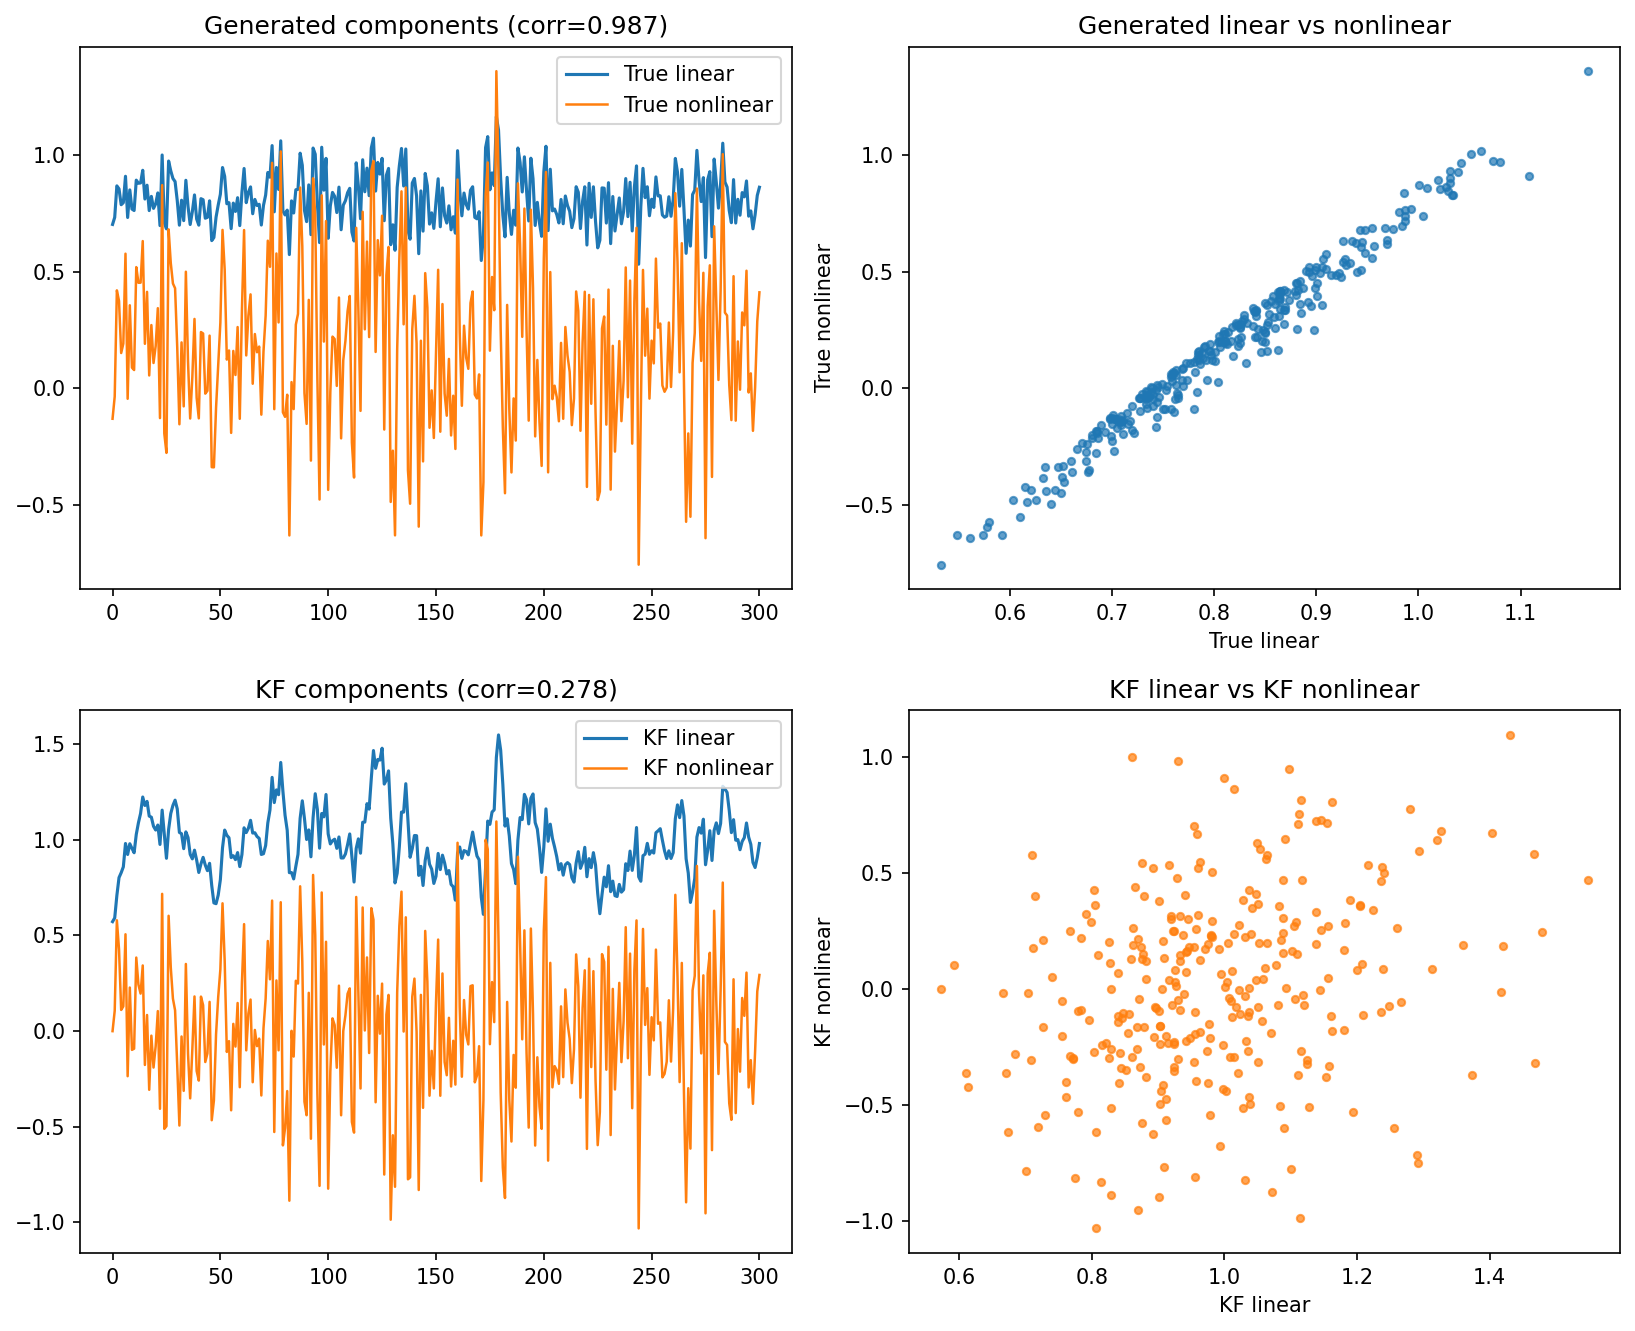

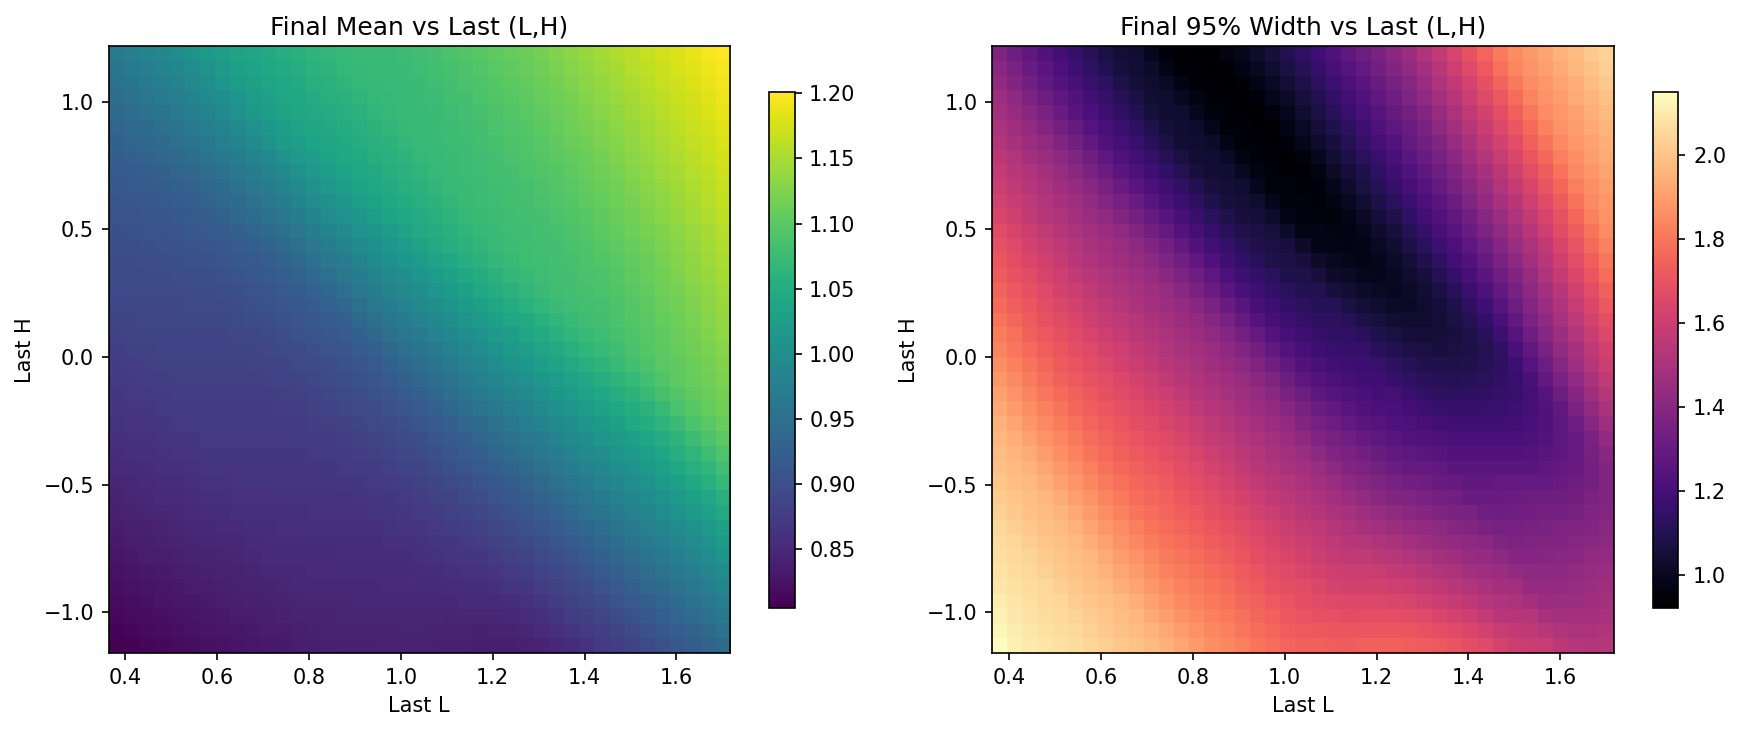

In [7]:
from pathlib import Path
from IPython.display import Image, display

base_dir = Path.cwd()
photo_dir = base_dir / "photo" if base_dir.name == "meeting" else base_dir / "meeting" / "photo"
photo_dir.mkdir(parents=True, exist_ok=True)

corr_plot_path = photo_dir / "garch_m_component_corr_notebook_h1.png"
interaction_plot_path = photo_dir / "garch_m_interaction_notebook_h1.png"
interval_plot_path = photo_dir / "garch_m_prediction_interval_notebook_h1.png"

save_component_correlation_plot(
    result["true_low_full"],
    result["true_high_full"],
    result["estimated_low_full"],
    result["estimated_high_full"],
    corr_plot_path,
)

save_interaction_plot(
    result["joint_bundle"],
    result["estimated_low_train"],
    result["estimated_high_train"],
    interaction_plot_path,
)


print(corr_plot_path)
print(interaction_plot_path)

display(Image(filename=str(corr_plot_path)))
display(Image(filename=str(interaction_plot_path)))


## GARCH-M 的 Monte Carlo 摘要實驗

這一段會重複執行多次 GARCH-M 模擬實驗，彙整 MSE、coverage、interval width，以及 component correlation 的平均表現。


Mode                          : GARCH-M Joint (L,H) DistPred-style ensemble
Monte Carlo runs               : 50
Observed sample size T         : 300
Ensemble samples K             : 50

h | Mean low MSE | Mean high MSE | Mean noisy MSE | Mean noisy coverage | Mean interval width
--|--------------|---------------|----------------|---------------------|--------------------
5 | 0.0596       | 0.2097        | 0.2546         | 89.60%               | 1.8878
    Avg timing (s/run): data=0.00, point_fit=2.17
    Avg model breakdown (s/run): kf=0.00, joint=2.17
    Avg sample width: low=0.5995, high=1.5540, final=1.8878
    Avg component corr: generated=0.9854 (R^2=0.9711), KF=0.2808 (R^2=0.0812)
    Saved interaction plot     : c:\Users\allen\OneDrive\Desktop\程式\meeting\photo\garch_m_interaction_h5.png
    Saved component corr plot  : c:\Users\allen\OneDrive\Desktop\程式\meeting\photo\garch_m_component_corr_h5.png
    Saved interval plot        : c:\Users\allen\OneDrive\Desktop\程式\meeting\photo\

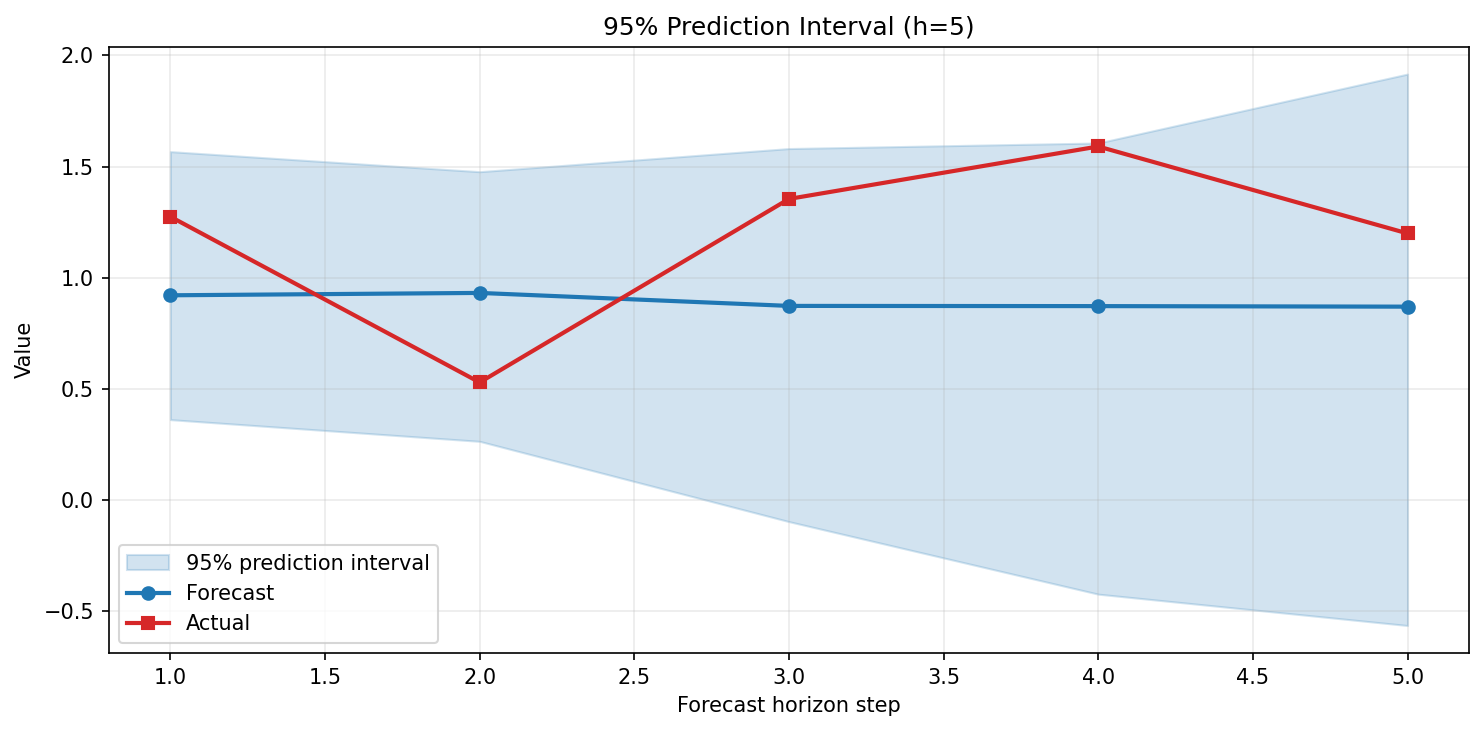

10 | 0.0641       | 0.1764        | 0.2442         | 93.20%               | 2.4253
    Avg timing (s/run): data=0.00, point_fit=2.24
    Avg model breakdown (s/run): kf=0.00, joint=2.24
    Avg sample width: low=0.8690, high=1.8038, final=2.4253
    Avg component corr: generated=0.9855 (R^2=0.9712), KF=0.2809 (R^2=0.0813)
    Saved interaction plot     : c:\Users\allen\OneDrive\Desktop\程式\meeting\photo\garch_m_interaction_h10.png
    Saved component corr plot  : c:\Users\allen\OneDrive\Desktop\程式\meeting\photo\garch_m_component_corr_h10.png
    Saved interval plot        : c:\Users\allen\OneDrive\Desktop\程式\meeting\photo\garch_m_prediction_interval_h10.png


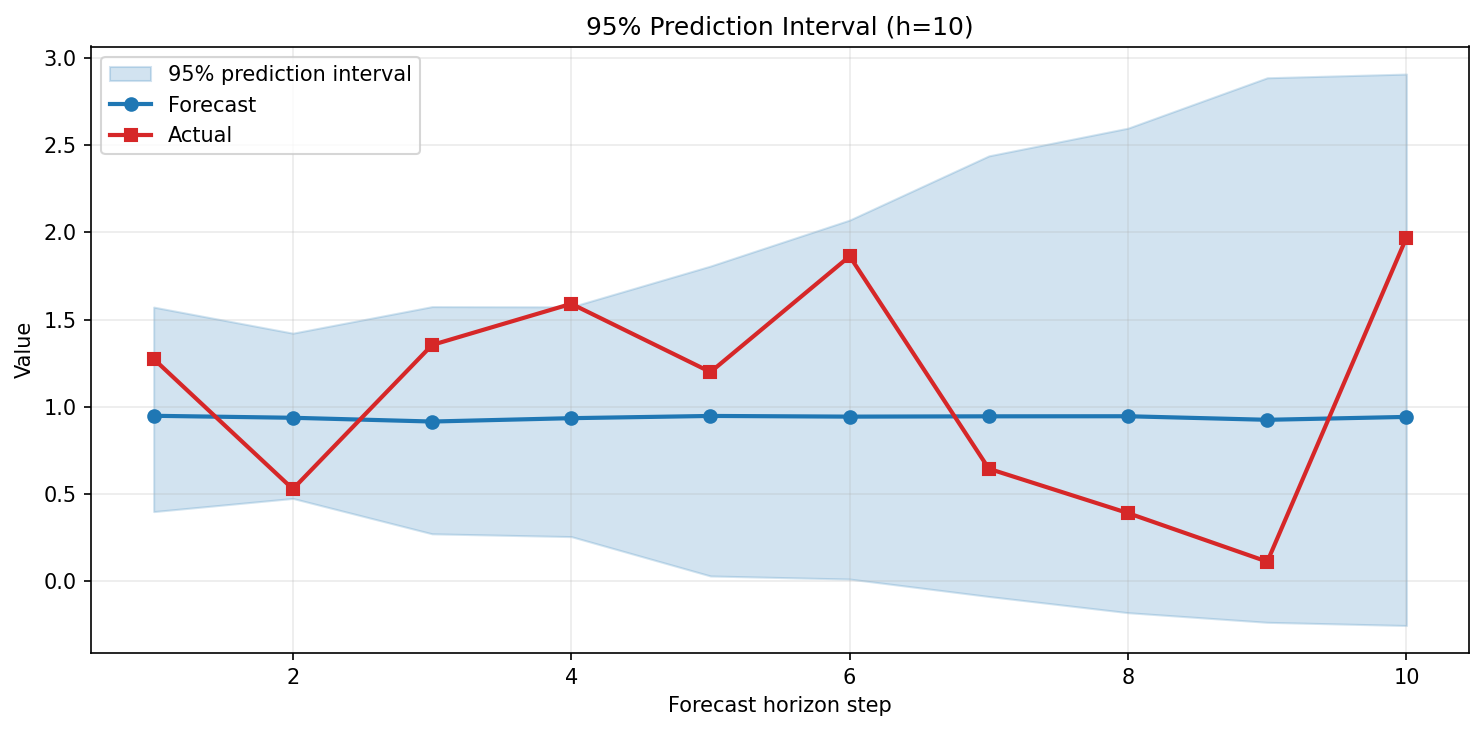

25 | 0.0628       | 0.1880        | 0.2721         | 96.72%               | 3.1503
    Avg timing (s/run): data=0.00, point_fit=2.22
    Avg model breakdown (s/run): kf=0.00, joint=2.22
    Avg sample width: low=1.1290, high=2.1944, final=3.1503
    Avg component corr: generated=0.9855 (R^2=0.9712), KF=0.2837 (R^2=0.0829)
    Saved interaction plot     : c:\Users\allen\OneDrive\Desktop\程式\meeting\photo\garch_m_interaction_h25.png
    Saved component corr plot  : c:\Users\allen\OneDrive\Desktop\程式\meeting\photo\garch_m_component_corr_h25.png
    Saved interval plot        : c:\Users\allen\OneDrive\Desktop\程式\meeting\photo\garch_m_prediction_interval_h25.png


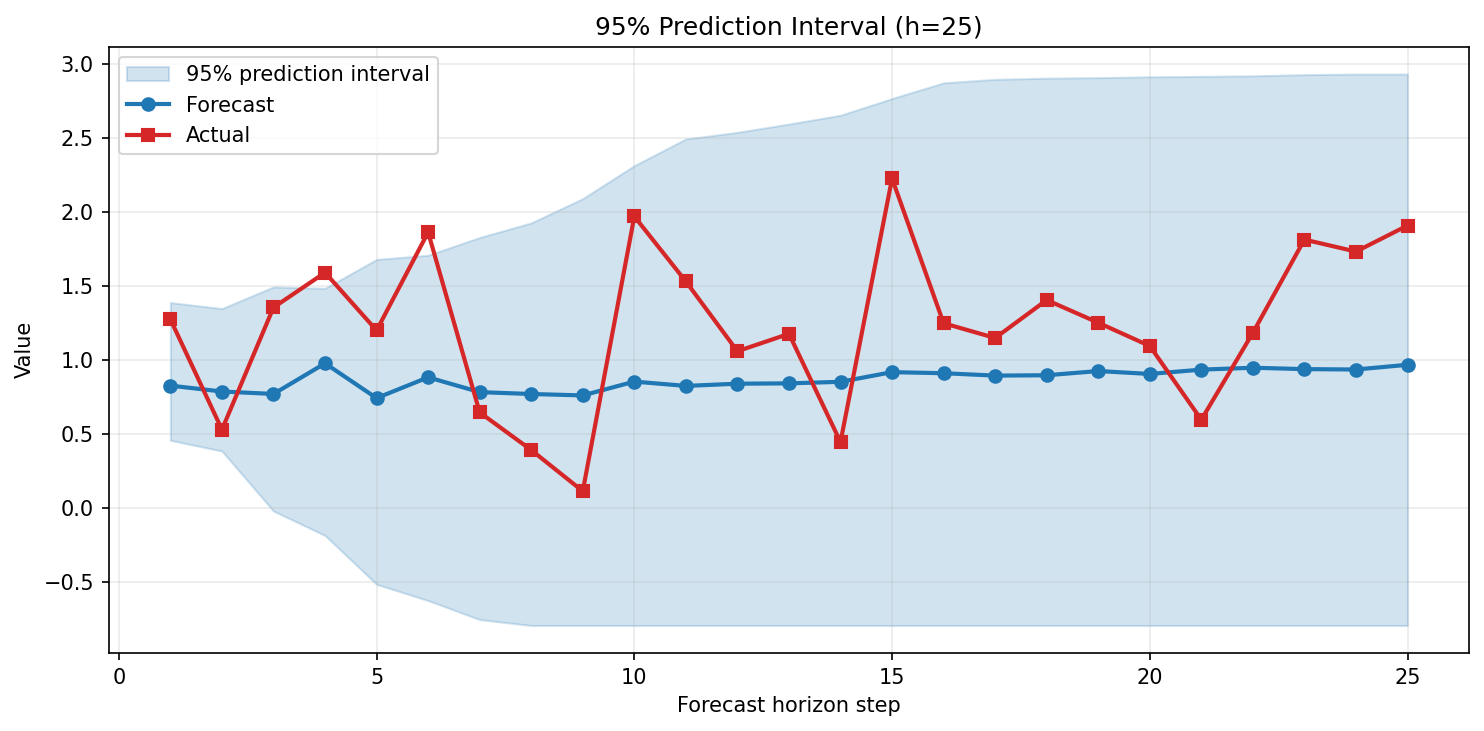

50 | 0.0619       | 0.1925        | 0.2795         | 98.16%               | 3.4031
    Avg timing (s/run): data=0.00, point_fit=2.22
    Avg model breakdown (s/run): kf=0.00, joint=2.22
    Avg sample width: low=1.2168, high=2.2851, final=3.4031
    Avg component corr: generated=0.9852 (R^2=0.9706), KF=0.2834 (R^2=0.0823)
    Saved interaction plot     : c:\Users\allen\OneDrive\Desktop\程式\meeting\photo\garch_m_interaction_h50.png
    Saved component corr plot  : c:\Users\allen\OneDrive\Desktop\程式\meeting\photo\garch_m_component_corr_h50.png
    Saved interval plot        : c:\Users\allen\OneDrive\Desktop\程式\meeting\photo\garch_m_prediction_interval_h50.png


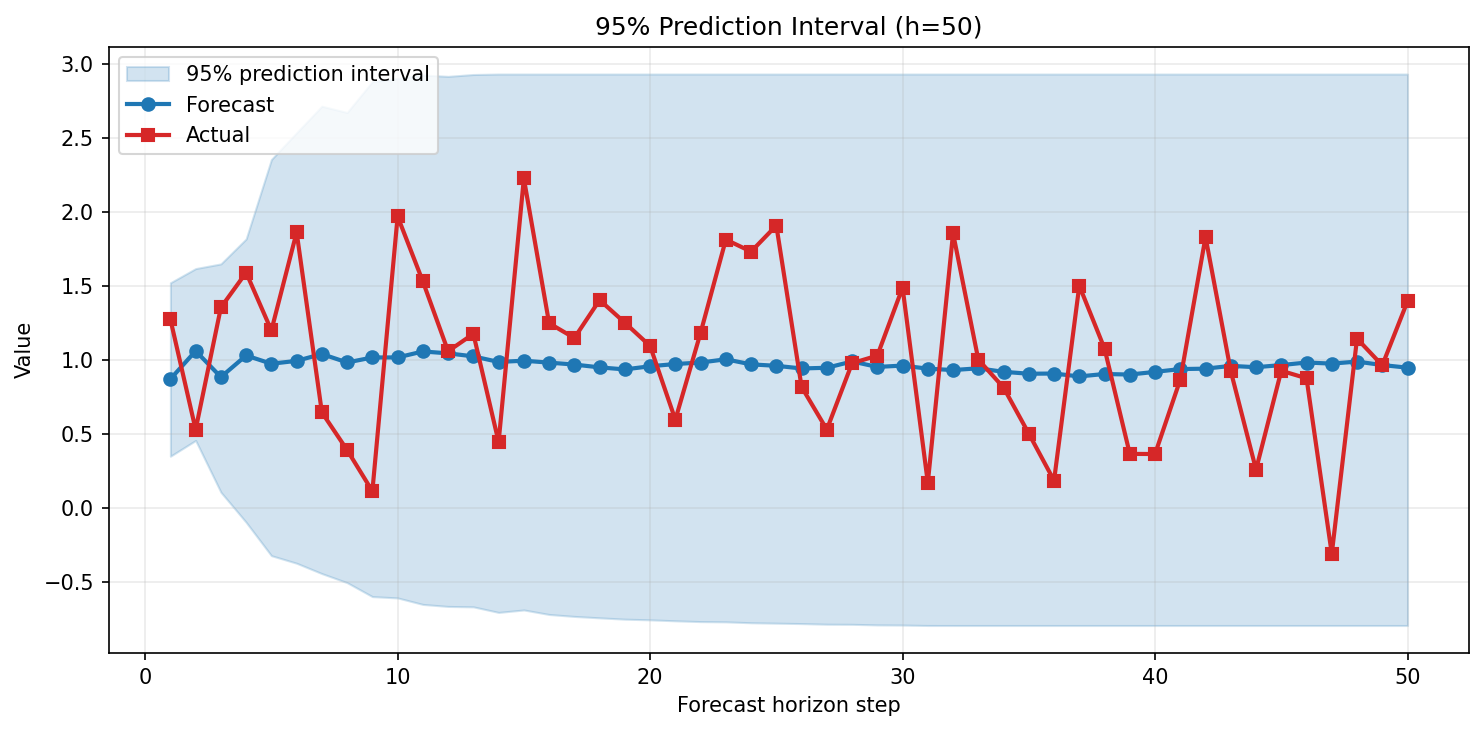


Elapsed time                   : 451.90 seconds


In [8]:
from IPython.display import Image, display

n_monte_carlo = 50
train_size = 300
horizons = [5,10,25,50]
ensemble_size = 50

print("Mode                          : GARCH-M Joint (L,H) DistPred-style ensemble")
print(f"Monte Carlo runs               : {n_monte_carlo}")
print(f"Observed sample size T         : {train_size}")
print(f"Ensemble samples K             : {ensemble_size}")
print("")
print("h | Mean low MSE | Mean high MSE | Mean noisy MSE | Mean noisy coverage | Mean interval width")
print("--|--------------|---------------|----------------|---------------------|--------------------")

start_time = time.perf_counter()

for horizon in horizons:
    experiment_results = []
    for run_idx in range(n_monte_carlo):
        np.random.seed(42 + run_idx)
        experiment_results.append(
            run_single_experiment(
                train_size=train_size,
                horizon=horizon,
                ensemble_size=ensemble_size,
            )
        )

    low_mses = np.array([result["low_mse"] for result in experiment_results], dtype=float)
    high_mses = np.array([result["high_mse"] for result in experiment_results], dtype=float)
    noisy_mses = np.array([result["final_noisy_mse"] for result in experiment_results], dtype=float)
    noisy_coverages = np.array([result["noisy_coverage"] for result in experiment_results], dtype=float)
    mean_interval_widths = np.array([result["mean_interval_width"] for result in experiment_results], dtype=float)
    low_sample_widths = np.array([result["low_sample_width"] for result in experiment_results], dtype=float)
    high_sample_widths = np.array([result["high_sample_width"] for result in experiment_results], dtype=float)
    final_sample_widths = np.array([result["final_sample_width"] for result in experiment_results], dtype=float)
    true_component_corrs = np.array(
        [result["true_component_corr"]["pearson_corr"] for result in experiment_results],
        dtype=float,
    )
    kf_component_corrs = np.array(
        [result["kf_component_corr"]["pearson_corr"] for result in experiment_results],
        dtype=float,
    )
    true_component_corrsq = np.array(
        [result["true_component_corr"]["corr_sq"] for result in experiment_results],
        dtype=float,
    )
    kf_component_corrsq = np.array(
        [result["kf_component_corr"]["corr_sq"] for result in experiment_results],
        dtype=float,
    )
    mean_data_generation = np.mean([result["timing_info"]["data_generation"] for result in experiment_results])
    mean_point_forecast_fit = np.mean([result["timing_info"]["point_forecast_fit"] for result in experiment_results])
    mean_kf_decomposition = np.mean([result["timing_info"]["kf_decomposition"] for result in experiment_results])
    mean_joint_distpred_fit_forecast = np.mean(
        [result["timing_info"]["joint_distpred_fit_forecast"] for result in experiment_results]
    )

    print(
        f"{horizon} | "
        f"{np.mean(low_mses):.4f}       | "
        f"{np.mean(high_mses):.4f}        | "
        f"{np.mean(noisy_mses):.4f}         | "
        f"{np.mean(noisy_coverages):.2f}%               | "
        f"{np.mean(mean_interval_widths):.4f}"
    )
    print(
        "    Avg timing (s/run): "
        f"data={mean_data_generation:.2f}, "
        f"point_fit={mean_point_forecast_fit:.2f}"
    )
    print(
        "    Avg model breakdown (s/run): "
        f"kf={mean_kf_decomposition:.2f}, "
        f"joint={mean_joint_distpred_fit_forecast:.2f}"
    )
    print(
        "    Avg sample width: "
        f"low={np.mean(low_sample_widths):.4f}, "
        f"high={np.mean(high_sample_widths):.4f}, "
        f"final={np.mean(final_sample_widths):.4f}"
    )
    print(
        "    Avg component corr: "
        f"generated={np.mean(true_component_corrs):.4f} (R^2={np.mean(true_component_corrsq):.4f}), "
        f"KF={np.mean(kf_component_corrs):.4f} (R^2={np.mean(kf_component_corrsq):.4f})"
    )

    representative = experiment_results[0]
    base_dir = Path.cwd()
    photo_dir = base_dir / "photo" if base_dir.name == "meeting" else base_dir / "meeting" / "photo"
    photo_dir.mkdir(parents=True, exist_ok=True)

    plot_path = photo_dir / f"garch_m_interaction_h{horizon}.png"
    save_interaction_plot(
        representative["joint_bundle"],
        representative["estimated_low_train"],
        representative["estimated_high_train"],
        plot_path,
    )
    print(f"    Saved interaction plot     : {plot_path}")

    corr_plot_path = photo_dir / f"garch_m_component_corr_h{horizon}.png"
    save_component_correlation_plot(
        representative["true_low_full"],
        representative["true_high_full"],
        representative["estimated_low_full"],
        representative["estimated_high_full"],
        corr_plot_path,
    )
    print(f"    Saved component corr plot  : {corr_plot_path}")

    interval_plot_path = photo_dir / f"garch_m_prediction_interval_h{horizon}.png"
    save_prediction_interval_plot(
        representative["measurements_test"],
        representative["final_forecast"],
        representative["interval_lower"],
        representative["interval_upper"],
        interval_plot_path,
        title=f"95% Prediction Interval (h={horizon})",
    )
    print(f"    Saved interval plot        : {interval_plot_path}")
    display(Image(filename=str(interval_plot_path)))

elapsed_seconds = time.perf_counter() - start_time
print("")
print(f"Elapsed time                   : {elapsed_seconds:.2f} seconds")
